1. Latency

2. Memory Usage

3. Context Length

4. Response Length

5. Context Relevance

In [1]:
# ============================================================
# IMPORT REQUIRED LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer

from sklearn.metrics.pairwise import cosine_similarity

In [2]:
# ============================================================
# LOAD ALL PIPELINE RESULTS
# ============================================================

dense_gpt4o = pd.read_csv(
    "dense_gpt4o_results.csv"
)

hybrid_gpt4o = pd.read_csv(
    "hybrid_gpt4o_results.csv"
)

fusion_gpt4o = pd.read_csv(
    "fusion_gpt4o_results.csv"
)

dense_llama3 = pd.read_csv(
    "dense_llama3_results.csv"
)

hybrid_llama3 = pd.read_csv(
    "hybrid_llama3_results.csv"
)

fusion_llama3 = pd.read_csv(
    "fusion_llama3_results.csv"
)

dense_mistral = pd.read_csv(
    "dense_mistral_results.csv"
)

hybrid_mistral = pd.read_csv(
    "hybrid_mistral_results.csv"
)

fusion_mistral = pd.read_csv(
    "fusion_mistral_results.csv"
)

print(
    "All CSV Files Loaded Successfully"
)

All CSV Files Loaded Successfully


In [3]:
# ============================================================
# MERGE ALL RESULTS
# ============================================================

all_results = pd.concat(

    [

        dense_gpt4o,
        hybrid_gpt4o,
        fusion_gpt4o,

        dense_llama3,
        hybrid_llama3,
        fusion_llama3,

        dense_mistral,
        hybrid_mistral,
        fusion_mistral

    ],

    ignore_index=True

)

print(
    "Total Records:",
    len(all_results)
)

Total Records: 180


In [4]:
# ============================================================
# VERIFY DATASET
# ============================================================

all_results.info()

<class 'pandas.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   pipeline          180 non-null    str    
 1   retrieval_method  180 non-null    str    
 2   model             180 non-null    str    
 3   query             180 non-null    str    
 4   retrieved_count   180 non-null    int64  
 5   retrieved_docs    180 non-null    str    
 6   context           180 non-null    str    
 7   context_length    180 non-null    int64  
 8   generated_answer  180 non-null    str    
 9   response_length   180 non-null    int64  
 10  latency_seconds   180 non-null    float64
 11  memory_mb         180 non-null    float64
dtypes: float64(2), int64(3), str(7)
memory usage: 1.2 MB


In [5]:
# ============================================================
# LATENCY COMPARISON
# ============================================================

latency_summary = (

    all_results

    .groupby(
        "pipeline"
    )

    ["latency_seconds"]

    .mean()

    .reset_index()

)

latency_summary

,pipeline,latency_seconds
0,Dense GPT4o,2.372218
1,Dense Llama3,27.117777
2,Dense Mistral,34.918896
3,Fusion GPT4o,3.087247
4,Fusion Llama3,43.530853
5,Fusion Mistral,55.972109
6,Hybrid GPT4o,2.075981
7,Hybrid Llama3,26.121070
8,Hybrid Mistral,37.481856


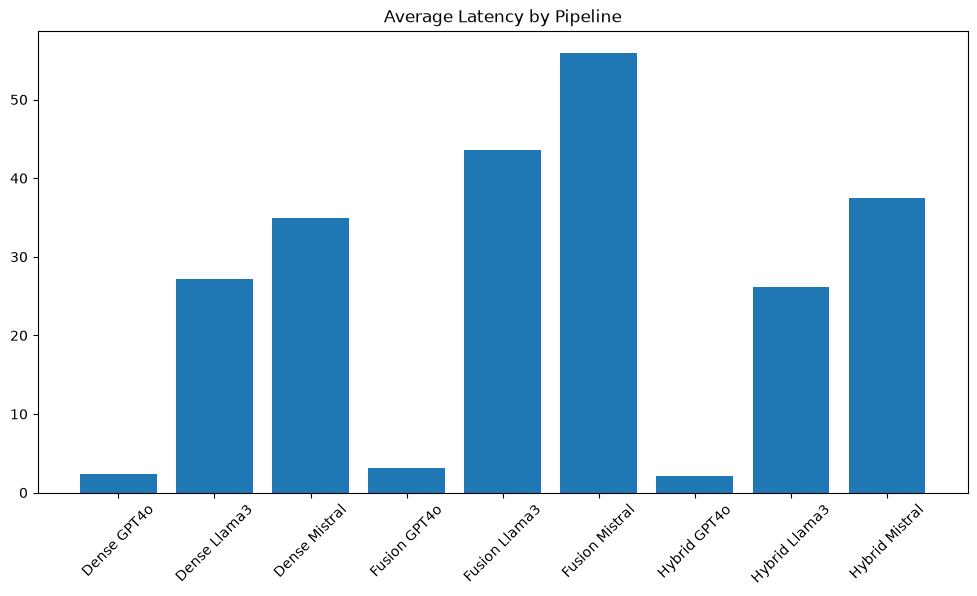

In [6]:
# ============================================================
# LATENCY BAR CHART
# ============================================================

plt.figure(
    figsize=(12,6)
)

plt.bar(

    latency_summary["pipeline"],

    latency_summary["latency_seconds"]

)

plt.xticks(
    rotation=45
)

plt.title(
    "Average Latency by Pipeline"
)

plt.show()

In [7]:
# ============================================================
# MEMORY COMPARISON
# ============================================================

memory_summary = (

    all_results

    .groupby(
        "pipeline"
    )

    ["memory_mb"]

    .mean()

    .reset_index()

)

memory_summary

,pipeline,memory_mb
0,Dense GPT4o,0.032031
1,Dense Llama3,46.063281
2,Dense Mistral,6.814063
3,Fusion GPT4o,75.105469
4,Fusion Llama3,-8.750781
5,Fusion Mistral,-5.067188
6,Hybrid GPT4o,8.346875
7,Hybrid Llama3,24.373438
8,Hybrid Mistral,-1.607813


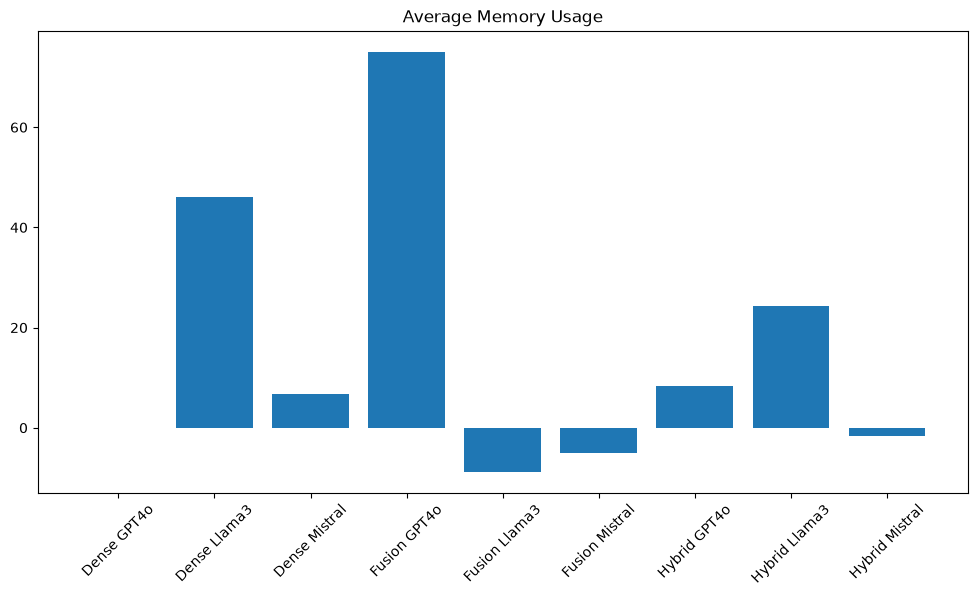

In [8]:
# ============================================================
# MEMORY BAR CHART
# ============================================================

plt.figure(
    figsize=(12,6)
)

plt.bar(

    memory_summary["pipeline"],

    memory_summary["memory_mb"]

)

plt.xticks(
    rotation=45
)

plt.title(
    "Average Memory Usage"
)

plt.show()

In [9]:
# ============================================================
# CONTEXT LENGTH ANALYSIS
# ============================================================

context_summary = (

    all_results

    .groupby(
        "pipeline"
    )

    ["context_length"]

    .mean()

    .reset_index()

)

context_summary

,pipeline,context_length
0,Dense GPT4o,2143.35
1,Dense Llama3,2143.35
2,Dense Mistral,2143.20
3,Fusion GPT4o,4541.65
4,Fusion Llama3,4615.55
5,Fusion Mistral,4714.35
6,Hybrid GPT4o,2226.05
7,Hybrid Llama3,2226.05
8,Hybrid Mistral,2226.20


In [10]:
# ============================================================
# RESPONSE LENGTH ANALYSIS
# ============================================================

response_summary = (

    all_results

    .groupby(
        "pipeline"
    )

    ["response_length"]

    .mean()

    .reset_index()

)

response_summary

,pipeline,response_length
0,Dense GPT4o,673.95
1,Dense Llama3,701.80
2,Dense Mistral,668.15
3,Fusion GPT4o,734.80
4,Fusion Llama3,947.45
5,Fusion Mistral,791.05
6,Hybrid GPT4o,550.85
7,Hybrid Llama3,823.65
8,Hybrid Mistral,679.65


Query
↓

Context

↓

Semantic Similarity

↓

Context Relevance Score


##HIGHER IS BETTER

In [11]:
# ============================================================
# LOAD EMBEDDING MODEL
# ============================================================

from langchain_openai import OpenAIEmbeddings

embedding_model = OpenAIEmbeddings(
    model="text-embedding-3-small"
)
print(
    "Embedding Model Loaded"
)

Embedding Model Loaded


In [13]:
# ============================================================
# CALCULATE CONTEXT RELEVANCE
# ============================================================

from sklearn.metrics.pairwise import cosine_similarity

scores = []

for _, row in all_results.iterrows():

    query = str(
        row["query"]
    )

    context = str(
        row["context"]
    )

    # --------------------------------------------------------
    # CREATE EMBEDDINGS
    # --------------------------------------------------------

    query_embedding = embedding_model.embed_query(
        query
    )

    context_embedding = embedding_model.embed_query(
        context[:8000]
    )

    # --------------------------------------------------------
    # COSINE SIMILARITY
    # --------------------------------------------------------

    similarity = cosine_similarity(

        [query_embedding],

        [context_embedding]

    )[0][0]

    scores.append(
        similarity
    )

# ------------------------------------------------------------
# ADD SCORE COLUMN
# ------------------------------------------------------------

all_results[
    "context_relevance"
] = scores

print(
    "Context Relevance Calculated Successfully"
)

Context Relevance Calculated Successfully


In [14]:
# ============================================================
# CONTEXT RELEVANCE SUMMARY
# ============================================================

relevance_summary = (

    all_results

    .groupby(
        "pipeline"
    )

    ["context_relevance"]

    .mean()

    .reset_index()

)

relevance_summary

,pipeline,context_relevance
0,Dense GPT4o,0.562219
1,Dense Llama3,0.562183
2,Dense Mistral,0.561498
3,Fusion GPT4o,0.541738
4,Fusion Llama3,0.538999
5,Fusion Mistral,0.546440
6,Hybrid GPT4o,0.558679
7,Hybrid Llama3,0.558740
8,Hybrid Mistral,0.558867


In [15]:
# ============================================================
# FINAL PERFORMANCE TABLE
# ============================================================

final_performance = (

    all_results

    .groupby(
        "pipeline"
    )

    .agg({

        "latency_seconds":"mean",

        "memory_mb":"mean",

        "context_length":"mean",

        "response_length":"mean",

        "context_relevance":"mean"

    })

    .reset_index()

)

final_performance

,pipeline,latency_seconds,memory_mb,context_length,response_length,context_relevance
0,Dense GPT4o,2.372218,0.032031,2143.35,673.95,0.562219
1,Dense Llama3,27.117777,46.063281,2143.35,701.80,0.562183
2,Dense Mistral,34.918896,6.814063,2143.20,668.15,0.561498
3,Fusion GPT4o,3.087247,75.105469,4541.65,734.80,0.541738
4,Fusion Llama3,43.530853,-8.750781,4615.55,947.45,0.538999
5,Fusion Mistral,55.972109,-5.067188,4714.35,791.05,0.546440
6,Hybrid GPT4o,2.075981,8.346875,2226.05,550.85,0.558679
7,Hybrid Llama3,26.121070,24.373438,2226.05,823.65,0.558740
8,Hybrid Mistral,37.481856,-1.607813,2226.20,679.65,0.558867


In [16]:
print(all_results.columns.tolist())

['pipeline', 'retrieval_method', 'model', 'query', 'retrieved_count', 'retrieved_docs', 'context', 'context_length', 'generated_answer', 'response_length', 'latency_seconds', 'memory_mb', 'context_relevance']
